Coneccion con Drive y librerias


In [37]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q pyarrow geopandas openpyxl mapclassify

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import pyarrow.parquet as pq
import warnings
warnings.filterwarnings("ignore")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Parte 0: Carga y joins

In [32]:
# Rutas
BASE_PATH = "/content/drive/MyDrive/Tarea1_Censo/viv_hog_per_censo2024"

VIV_PATH = os.path.join(BASE_PATH, "viviendas_censo2024.parquet")
HOG_PATH = os.path.join(BASE_PATH, "hogares_censo2024.parquet")
PER_PATH = os.path.join(BASE_PATH, "personas_censo2024.parquet")

print("Existe BASE_PATH:", os.path.exists(BASE_PATH))
print("Archivos en carpeta:", os.listdir(BASE_PATH))
print("Existe VIV_PATH :", os.path.exists(VIV_PATH))
print("Existe HOG_PATH :", os.path.exists(HOG_PATH))
print("Existe PER_PATH :", os.path.exists(PER_PATH))

print("\nColumnas vivienda:")
print(pq.read_schema(VIV_PATH).names)

print("\nColumnas hogar:")
print(pq.read_schema(HOG_PATH).names)

print("\nColumnas persona:")
print(pq.read_schema(PER_PATH).names)

# Paso 0.1: cargar columnas necesarias

viv_cols = [
    "id_vivienda",
    "region",
    "comuna"
]

hog_cols = [
    "id_vivienda",
    "id_hogar"
]

per_cols = [
    "id_vivienda",
    "id_hogar",
    "id_persona",
    "sexo",
    "edad",
    "p27_nacionalidad_esp",
    "p25_lug_nacimiento_rec",
    "p24_lug_resid5",
    "p25_lug_nacimiento",
    "p26_llegada_periodo",
    "escolaridad",
    "cine11",
    "sit_fuerza_trabajo",
    "cod_ciuo",
    "cod_caenes",
    "p45_medio_transporte"
]

vivienda = pd.read_parquet(VIV_PATH, columns=viv_cols)
hogar = pd.read_parquet(HOG_PATH, columns=hog_cols)
persona = pd.read_parquet(PER_PATH, columns=per_cols)

print("\nShapes originales")
print("vivienda shape:", vivienda.shape)
print("hogar shape   :", hogar.shape)
print("persona shape :", persona.shape)

# Ajustar nombre para seguir la lógica de la pauta
vivienda = vivienda.rename(columns={"comuna": "codigo_comuna"})

# Paso 0.2: filtrar comunas
MY_COMUNAS = [13104,13126,13109]  # Conchali,Quinta Normal y La Cisterna

viv = vivienda[vivienda["codigo_comuna"].isin(MY_COMUNAS)].copy()
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

print("\nFilas después del filtro")
print("Filas vivienda:", len(viv))
print("Filas hogar   :", len(hog))
print("Filas persona :", len(per))

print("\nCódigos de comuna filtrados:")
print(viv["codigo_comuna"].drop_duplicates().sort_values().tolist())

# Paso 0.3: joins

df = (
    per.merge(hog, on=["id_vivienda", "id_hogar"], how="left")
       .merge(viv, on="id_vivienda", how="left")
)

# Agregar nombre de comuna (diccionario)
comuna_names = {
    13104: "Conchalí",
    13109: "La Cisterna",
    13126: "Quinta Normal"
}

df["nombre_comuna"] = df["codigo_comuna"].map(comuna_names)

assert len(df) == len(per), "Error: el join cambió el número de filas"

print("\ndf.shape:", df.shape)
print("\nInfo de df:")
df.info()

print("\nPrimeras filas:")
display(df.head())

Existe BASE_PATH: True
Archivos en carpeta: ['personas_censo2024.parquet', 'viviendas_censo2024.parquet', 'hogares_censo2024.parquet', 'comunas.shp', 'comunas.sbx', 'comunas.dbf', 'comunas.shx']
Existe VIV_PATH : True
Existe HOG_PATH : True
Existe PER_PATH : True

Columnas vivienda:
['id_vivienda', 'region', 'provincia', 'comuna', 'comuna_bajo_umbral', 'area', 'tipo_operativo', 'cant_hog', 'cant_per', 'p2_tipo_vivienda', 'p3a_estado_ocupacion', 'p3b_estado_ocupacion', 'p4a_mat_paredes', 'p4b_mat_techo', 'p4c_mat_piso', 'p5_num_dormitorios', 'p6_fuente_agua', 'p7_distrib_agua', 'p8_serv_hig', 'p9_fuente_elect', 'p10_basura', 'p11a_num_personas', 'p11b_comparte_gasto', 'p11c_num_hogar', 'indice_hacinamiento']

Columnas hogar:
['id_vivienda', 'id_hogar', 'region', 'provincia', 'comuna', 'comuna_bajo_umbral', 'area', 'tipo_operativo', 'p12_tenencia_viv', 'p13_comb_cocina', 'p14_comb_calefaccion', 'p15a_serv_tel_movil', 'p15b_serv_compu', 'p15c_serv_tablet', 'p15d_serv_internet_fija', 'p15e

,id_vivienda,id_hogar,id_persona,sexo,edad,p27_nacionalidad_esp,p25_lug_nacimiento_rec,p24_lug_resid5,p25_lug_nacimiento,p26_llegada_periodo,escolaridad,cine11,sit_fuerza_trabajo,cod_ciuo,cod_caenes,p45_medio_transporte,region,codigo_comuna,nombre_comuna
0,26,1,1,2,27,152,1,2,2,NaN,17,9,1.0,2.0,M,2.0,13,13126,Quinta Normal
1,171,1,1,2,68,152,1,2,2,NaN,12,6,3.0,NaN,None,NaN,13,13126,Quinta Normal
2,171,1,2,1,68,152,1,2,2,NaN,19,10,3.0,NaN,None,NaN,13,13126,Quinta Normal
3,171,1,3,2,85,152,1,2,1,NaN,6,4,3.0,NaN,None,NaN,13,13126,Quinta Normal
4,281,1,1,1,41,152,1,2,2,NaN,12,7,1.0,8.0,H,1.0,13,13104,Conchalí


Parte 1: Perfil demográfico

sexo
sexo
1    171406
2    182689
Name: count, dtype: int64

p25_lug_nacimiento_rec
p25_lug_nacimiento_rec
1.0    277827
2.0     73078
NaN      3190
Name: count, dtype: int64

sit_fuerza_trabajo
sit_fuerza_trabajo
1.0    173177
2.0     15857
3.0    103404
NaN     61657
Name: count, dtype: int64


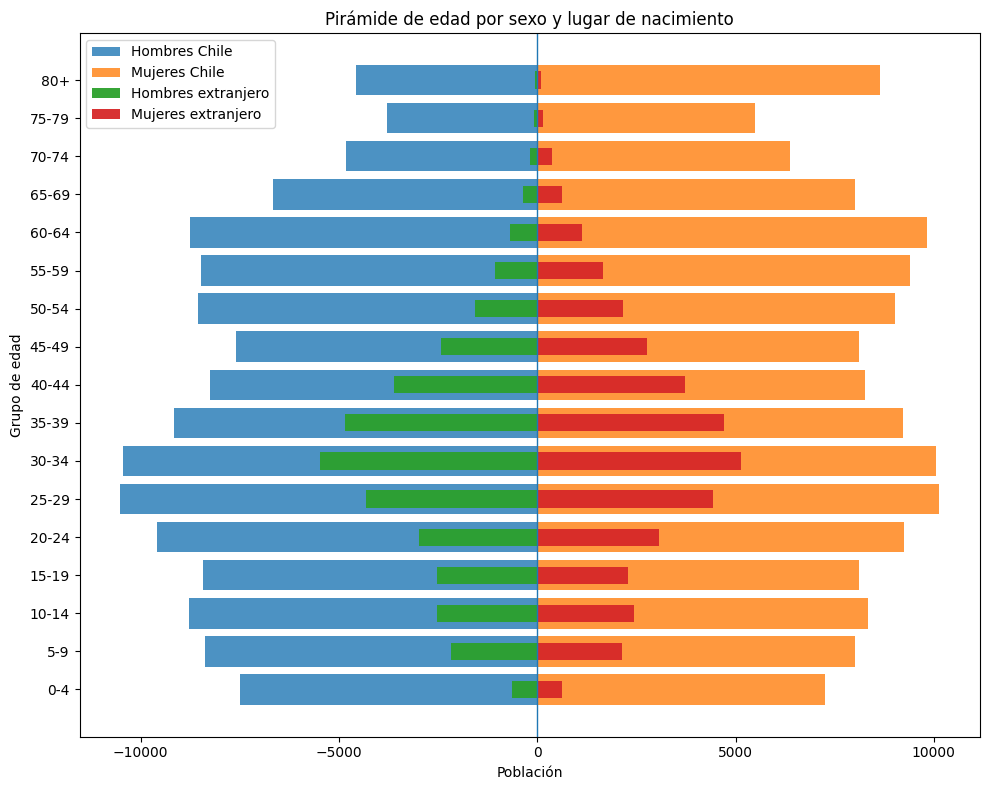


Dependency ratio:


/tmp/ipykernel_186/3549828129.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,nombre_comuna,pop_0_14,pop_15_64,pop_65_plus,dependency_ratio
0,Conchalí,20108,82231,19248,0.478603
1,La Cisterna,17137,71244,14776,0.447939
2,Quinta Normal,22064,90143,17144,0.434953


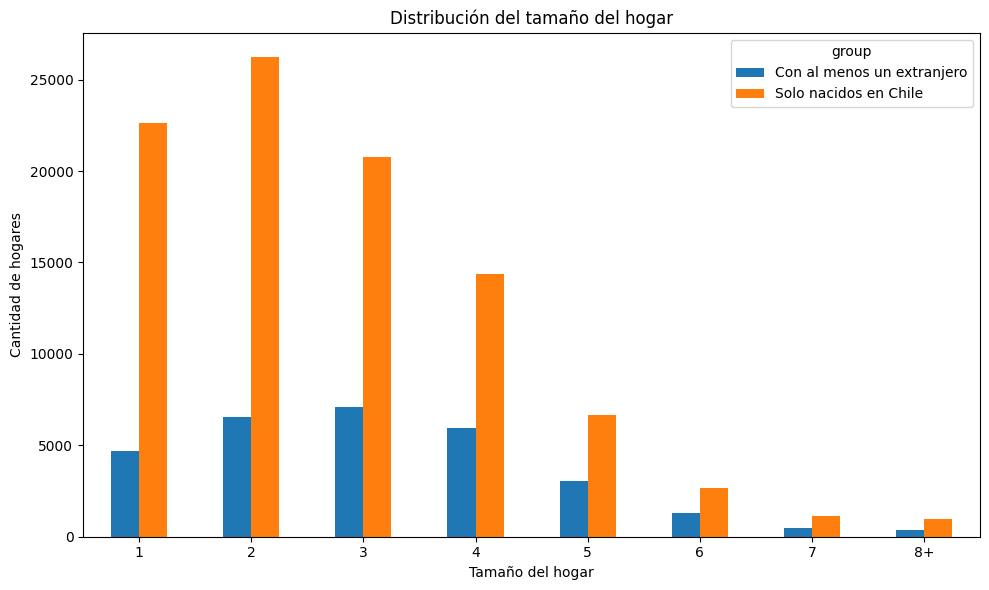


Educación y empleo:


,nombre_comuna,origen,mean_schooling,employment_rate
0,Conchalí,Chileno,11.403035,0.610368
1,Conchalí,Extranjero,12.096618,0.751594
2,La Cisterna,Chileno,12.914142,0.674777
3,La Cisterna,Extranjero,13.556787,0.788629
4,Quinta Normal,Chileno,12.114621,0.655829
5,Quinta Normal,Extranjero,12.824235,0.782267


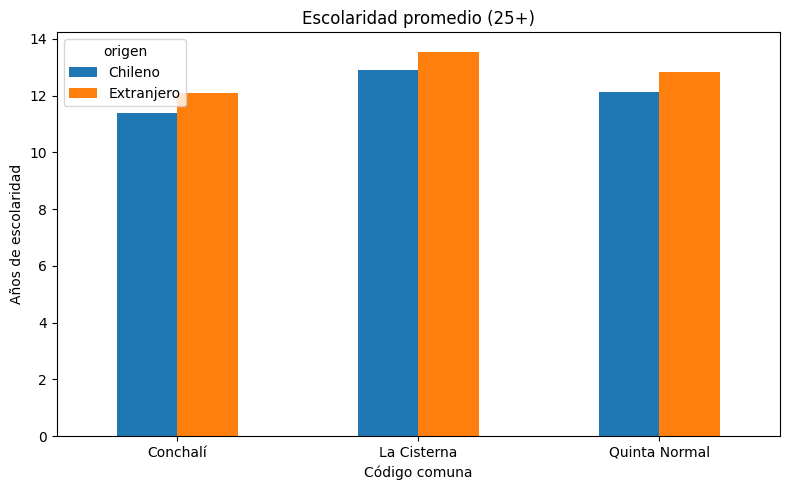

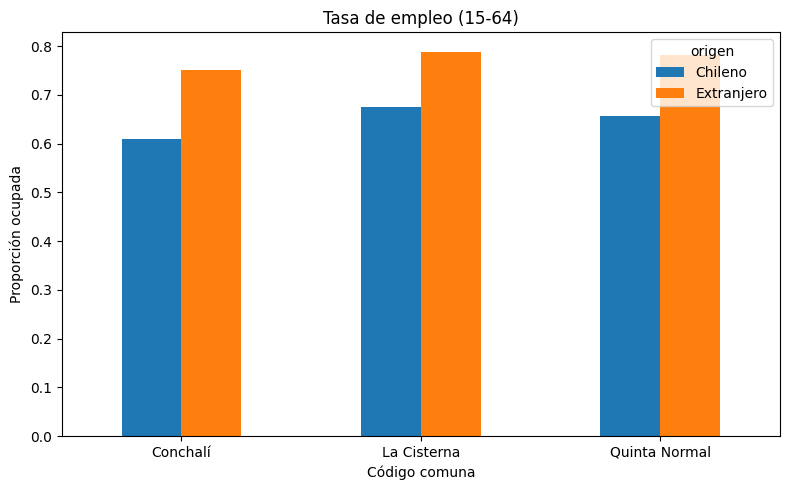

In [33]:
# PASO 1: Perfil demoráfico

df1 = df.copy()

# Limpieza de missing
cols_miss = [
    "edad", "escolaridad", "p25_lug_nacimiento_rec",
    "p24_lug_resid5", "p26_llegada_periodo", "sit_fuerza_trabajo"
]

for col in cols_miss:
    if col in df1.columns:
        df1[col] = df1[col].replace(-99, np.nan)

# Punto de revisión
print("sexo")
print(df1["sexo"].value_counts(dropna=False).sort_index())

print("\np25_lug_nacimiento_rec")
print(df1["p25_lug_nacimiento_rec"].value_counts(dropna=False).sort_index())

print("\nsit_fuerza_trabajo")
print(df1["sit_fuerza_trabajo"].value_counts(dropna=False).sort_index())


# Diccionario y ajustes de tabla

MALE_CODE = 1
FEMALE_CODE = 2

CHILEAN_BORN_CODE = 1
FOREIGN_BORN_CODE = 2

EMPLOYED_CODES = [1]


# 1.1 PIRÁMIDE DE EDAD

pyr = df1[df1["edad"].notna()].copy()

bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]

pyr["age_group"] = pd.cut(pyr["edad"], bins=bins, labels=labels, right=False)

pyr["sexo_label"] = pyr["sexo"].map({
    MALE_CODE: "Hombre",
    FEMALE_CODE: "Mujer"
})

pyr["origen_label"] = pyr["p25_lug_nacimiento_rec"].map({
    CHILEAN_BORN_CODE: "Nacido en Chile",
    FOREIGN_BORN_CODE: "Nacido en el extranjero"
})

pyr = pyr[
    pyr["sexo_label"].notna() &
    pyr["origen_label"].notna() &
    pyr["age_group"].notna()
].copy()

pyramid = (
    pyr.groupby(["age_group", "sexo_label", "origen_label"], observed=False)
       .size()
       .reset_index(name="n")
)

male_ch = (
    pyramid[(pyramid["sexo_label"] == "Hombre") & (pyramid["origen_label"] == "Nacido en Chile")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

male_for = (
    pyramid[(pyramid["sexo_label"] == "Hombre") & (pyramid["origen_label"] == "Nacido en el extranjero")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

female_ch = (
    pyramid[(pyramid["sexo_label"] == "Mujer") & (pyramid["origen_label"] == "Nacido en Chile")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

female_for = (
    pyramid[(pyramid["sexo_label"] == "Mujer") & (pyramid["origen_label"] == "Nacido en el extranjero")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

plt.figure(figsize=(10, 8))
y = np.arange(len(labels))

# Base: Nacidos en Chile
plt.barh(y, -male_ch.values, height=0.8, label="Hombres Chile", alpha=0.8)
plt.barh(y,  female_ch.values, height=0.8, label="Mujeres Chile", alpha=0.8)

# Overlay: Nacidos en el extranjero
plt.barh(y, -male_for.values, height=0.45, label="Hombres extranjero", alpha=0.95)
plt.barh(y,  female_for.values, height=0.45, label="Mujeres extranjero", alpha=0.95)

plt.yticks(y, labels)
plt.axvline(0, linewidth=1)
plt.xlabel("Población")
plt.ylabel("Grupo de edad")
plt.title("Pirámide de edad por sexo y lugar de nacimiento")
plt.tight_layout()
plt.legend()
plt.show()

# 1.2 Ratio de dependencia

dep = df1[df1["edad"].notna()].copy()

dependency = (
    dep.groupby("nombre_comuna")
       .apply(lambda x: pd.Series({
           "pop_0_14": ((x["edad"] >= 0) & (x["edad"] <= 14)).sum(),
           "pop_15_64": ((x["edad"] >= 15) & (x["edad"] <= 64)).sum(),
           "pop_65_plus": (x["edad"] >= 65).sum()
       }))
       .reset_index()
)

dependency["dependency_ratio"] = (
    (dependency["pop_0_14"] + dependency["pop_65_plus"]) /
    dependency["pop_15_64"]
)

print("\nDependency ratio:")
display(dependency)


# 1.3 TAMAÑO DEL HOGAR

hh_size = (
    df1.groupby(["id_vivienda", "id_hogar"])
       .agg(
           household_size=("id_persona", "count"),
           n_foreign=("p25_lug_nacimiento_rec", lambda s: (s == FOREIGN_BORN_CODE).sum())
       )
       .reset_index()
)

hh_size["group"] = np.where(
    hh_size["n_foreign"] > 0,
    "Con al menos un extranjero",
    "Solo nacidos en Chile"
)

hh_size["size_cat"] = hh_size["household_size"].clip(upper=8).astype(int).astype(str)
hh_size.loc[hh_size["household_size"] >= 8, "size_cat"] = "8+"

order_size = [str(i) for i in range(1, 8)] + ["8+"]

hh_plot = (
    hh_size.groupby(["size_cat", "group"])
           .size()
           .reset_index(name="n")
)

hh_plot["size_cat"] = pd.Categorical(hh_plot["size_cat"], categories=order_size, ordered=True)
hh_plot = hh_plot.sort_values("size_cat")

pivot_hh = hh_plot.pivot(index="size_cat", columns="group", values="n").fillna(0)

pivot_hh.plot(kind="bar", figsize=(10, 6))
plt.title("Distribución del tamaño del hogar")
plt.xlabel("Tamaño del hogar")
plt.ylabel("Cantidad de hogares")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 1.4 EDUCACIÓN Y EMPLEO

edu = df1[
    df1["edad"].notna() &
    (df1["edad"] >= 25) &
    df1["escolaridad"].notna() &
    df1["p25_lug_nacimiento_rec"].isin([CHILEAN_BORN_CODE, FOREIGN_BORN_CODE])
].copy()

edu["origen"] = edu["p25_lug_nacimiento_rec"].map({
    CHILEAN_BORN_CODE: "Chileno",
    FOREIGN_BORN_CODE: "Extranjero"
})

schooling = (
    edu.groupby(["nombre_comuna", "origen"])["escolaridad"]
       .mean()
       .reset_index(name="mean_schooling")
)

emp = df1[
    df1["edad"].notna() &
    df1["edad"].between(15, 64) &
    df1["sit_fuerza_trabajo"].notna() &
    df1["p25_lug_nacimiento_rec"].isin([CHILEAN_BORN_CODE, FOREIGN_BORN_CODE])
].copy()

emp["origen"] = emp["p25_lug_nacimiento_rec"].map({
    CHILEAN_BORN_CODE: "Chileno",
    FOREIGN_BORN_CODE: "Extranjero"
})

emp["empleado"] = emp["sit_fuerza_trabajo"].isin(EMPLOYED_CODES).astype(int)

employment = (
    emp.groupby(["nombre_comuna", "origen"])["empleado"]
       .mean()
       .reset_index(name="employment_rate")
)

edu_emp = schooling.merge(employment, on=["nombre_comuna", "origen"], how="outer")

print("\nEducación y empleo:")
display(edu_emp)

pivot_school = edu_emp.pivot(index="nombre_comuna", columns="origen", values="mean_schooling")
pivot_school.plot(kind="bar", figsize=(8, 5))
plt.title("Escolaridad promedio (25+)")
plt.xlabel("Código comuna")
plt.ylabel("Años de escolaridad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pivot_emp = edu_emp.pivot(index="nombre_comuna", columns="origen", values="employment_rate")
pivot_emp.plot(kind="bar", figsize=(8, 5))
plt.title("Tasa de empleo (15-64)")
plt.xlabel("Código comuna")
plt.ylabel("Proporción ocupada")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Comentario:

Las tres comunas analizadas presentan una estructura demográfica dominada por población en edad de trabajar, especialmente entre los 25 y 44 años. Esto se refleja en una pirámide con mayor concentración en edades laborales.

La población nacida en el extranjero se concentra aún más en estos grupos etarios, lo que sugiere que la migración está asociada principalmente a individuos en edad activa.

La razón de dependencia es relativamente baja en las tres comunas, lo que indica una estructura favorable desde el punto de vista económico, con una mayor proporción de población en edad productiva.

En cuanto al tamaño de los hogares, predominan los hogares pequeños (1 a 3 personas), aunque los hogares con presencia de población extranjera tienden a concentrarse en tamaños intermedios.

Finalmente, se observa que la población chilena presenta mayor escolaridad promedio, mientras que la población extranjera tiene mayores tasas de empleo, lo que sugiere una fuerte inserción laboral de los migrantes.

Parte 2: Panorama migratorio


% extranjeros por comuna:


/tmp/ipykernel_186/430075415.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,codigo_comuna,pop_total,pop_foreign,pct_foreign
0,13104,120957,17686,0.146217
1,13109,101971,19762,0.193800
2,13126,127977,35630,0.278409


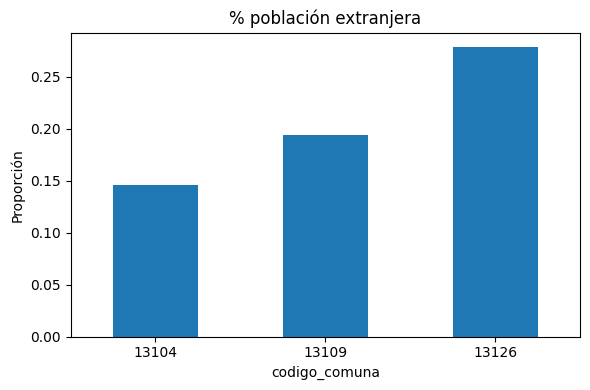

Top 10 nacionalidades:


,count,count
0,Argentina,479
1,Bolivia,1206
2,Haití,2743
3,Colombia,8960
4,Perú,15378
5,Venezuela,36837


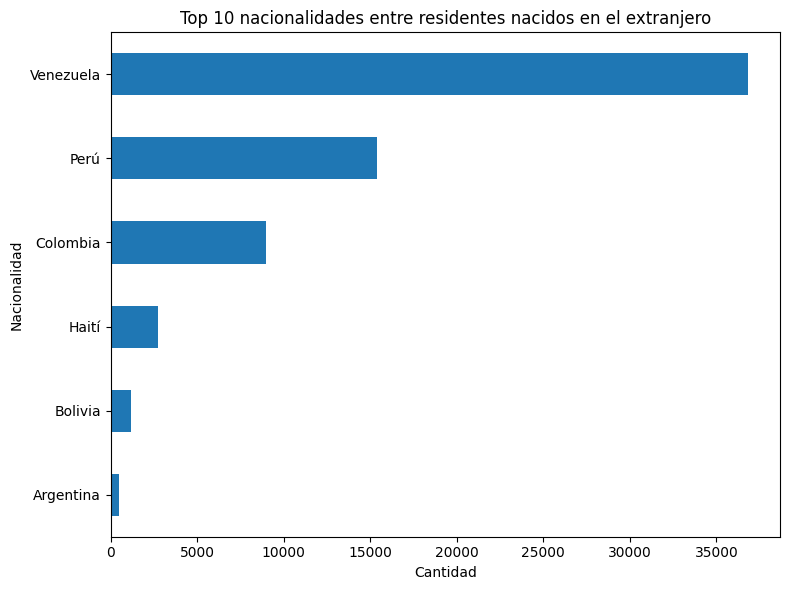

DEBUG códigos reales:
p24_lug_resid5
 2     245338
 3      60103
 4      29042
-99      3428
Name: count, dtype: int64
Residencia hace 5 años (%):


resid5_group,Extranjero,Otra comuna misma región,Otra región
comuna_label,,,
Conchalí,5.01,82.30,12.69
La Cisterna,8.72,65.52,25.76
Quinta Normal,12.13,71.11,16.75


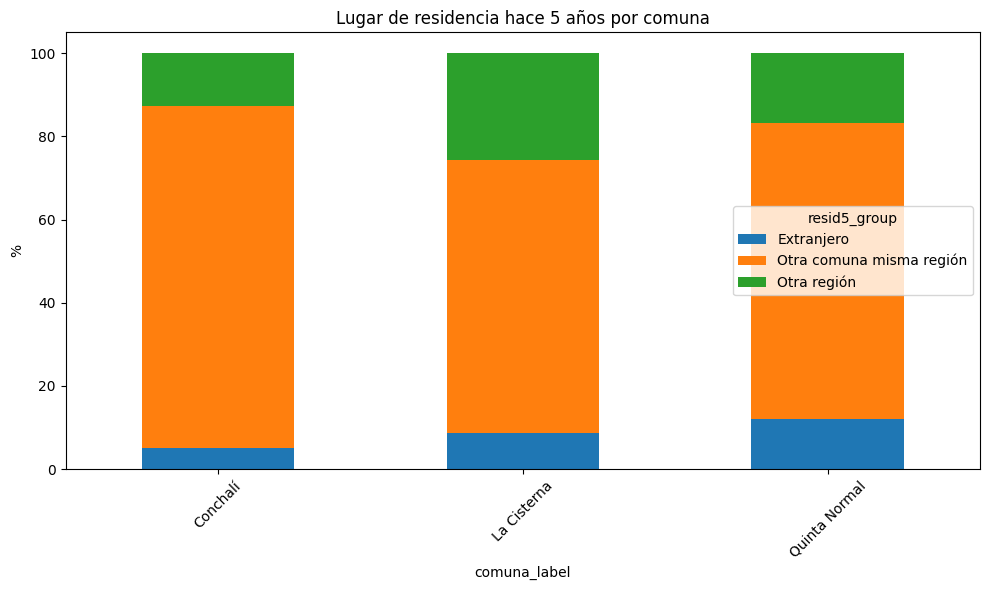

Período de llegada:


,count,count
0,Antes de 2000,8482
1,2000-2009,19921
2,2010-2016,25450
3,2017-2021,7656
4,2022-2024,4268


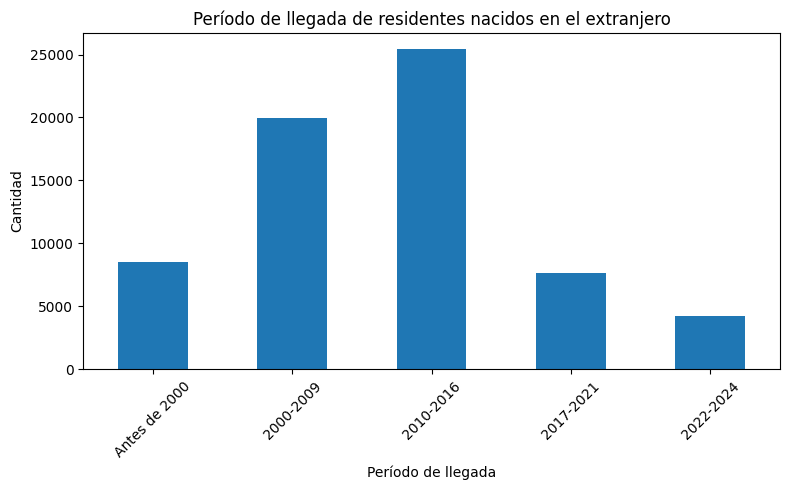

In [38]:

# PASO 2: Pasaje migratorio

df2 = df1.copy()

# 2.1: extranjeros por comuna

mig = df2[df2["p25_lug_nacimiento_rec"].notna()].copy()

mig_summary = (
    mig.groupby("codigo_comuna")
       .apply(lambda x: pd.Series({
           "pop_total": len(x),
           "pop_foreign": (x["p25_lug_nacimiento_rec"] == FOREIGN_BORN_CODE).sum()
       }))
       .reset_index()
)

mig_summary["pct_foreign"] = mig_summary["pop_foreign"] / mig_summary["pop_total"]

print("\n% extranjeros por comuna:")
display(mig_summary)

# Gráfico
mig_summary.plot(
    x="codigo_comuna",
    y="pct_foreign",
    kind="bar",
    legend=False,
    figsize=(6,4)
)
plt.title("% población extranjera")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2.2 Top 10 nacionalidades
# diccionario
COD_CHILEAN_BORN = 1
COD_FOREIGN_BORN = 2

nationality_map = {
    862: "Venezuela",
    604: "Perú",
    170: "Colombia",
    68: "Bolivia",
    32: "Argentina",
    218: "Ecuador",
    76: "Brasil",
    192: "Cuba",
    214: "República Dominicana",
    332: "Haití"
}

nat_df = df[
    (df["p25_lug_nacimiento_rec"] == COD_FOREIGN_BORN) &
    (df["p27_nacionalidad_esp"].notna())
].copy()

nat_df["nationality"] = nat_df["p27_nacionalidad_esp"].map(nationality_map)
nat_df = nat_df[nat_df["nationality"].notna()].copy()

top10_nat = nat_df["nationality"].value_counts().head(10).sort_values()

print("Top 10 nacionalidades:")
display(top10_nat.reset_index().rename(columns={"index": "nationality", "nationality": "count"}))

plt.figure(figsize=(8, 6))
top10_nat.plot(kind="barh")
plt.title("Top 10 nacionalidades entre residentes nacidos en el extranjero")
plt.xlabel("Cantidad")
plt.ylabel("Nacionalidad")
plt.tight_layout()
plt.show()

# 2.3 Residencia hace 5 años

resid5_map = {
    1: "Misma comuna",
    2: "Otra comuna misma región",
    3: "Otra región",
    4: "Extranjero"
}

comuna_names = {
    13104: "Conchalí",
    13109: "La Cisterna",
    13126: "Quinta Normal"
}

mig5 = df[
    (df["edad"].notna()) &
    (df["edad"] >= 5) &
    (df["p24_lug_resid5"].notna())
].copy()

print("DEBUG códigos reales:")
print(mig5["p24_lug_resid5"].value_counts(dropna=False))

mig5["resid5_group"] = mig5["p24_lug_resid5"].map(resid5_map)
mig5["comuna_label"] = mig5["codigo_comuna"].map(comuna_names)

mig5_tab = pd.crosstab(
    mig5["comuna_label"],
    mig5["resid5_group"],
    normalize="index"
) * 100

mig5_tab = mig5_tab.fillna(0)

print("Residencia hace 5 años (%):")
display(mig5_tab.round(2))

mig5_tab.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Lugar de residencia hace 5 años por comuna")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2.4 Período de llegada

# Códigos base
COD_CHILEAN_BORN = 1
COD_FOREIGN_BORN = 2

# Etiquetas ajustadas para la base.
arrival_map = {
    1: "Antes de 2000",
    2: "2000-2009",
    3: "2010-2016",
    4: "2017-2021",
    5: "2022-2024"
}

arrival_df = df[
    (df["p25_lug_nacimiento_rec"] == COD_FOREIGN_BORN) &
    (df["p26_llegada_periodo"].notna())
].copy()

arrival_df["arrival_period"] = arrival_df["p26_llegada_periodo"].map(arrival_map)
arrival_df = arrival_df[arrival_df["arrival_period"].notna()].copy()

arrival_order = list(arrival_map.values())
arrival_counts = (
    arrival_df["arrival_period"]
    .value_counts()
    .reindex(arrival_order, fill_value=0)
)

print("Período de llegada:")
display(
    arrival_counts
    .reset_index()
    .rename(columns={"index": "arrival_period", "arrival_period": "count"})
)

plt.figure(figsize=(8, 5))
arrival_counts.plot(kind="bar")
plt.title("Período de llegada de residentes nacidos en el extranjero")
plt.xlabel("Período de llegada")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Comentario:

Las tres comunas presentan una proporción significativa de población nacida en el extranjero, lo que confirma la importancia de la migración en estos territorios.

Las nacionalidades más frecuentes corresponden principalmente a países de América Latina, lo que evidencia patrones migratorios regionales.

En cuanto a la residencia hace cinco años, se observa una alta movilidad dentro de la misma región, junto con una fracción relevante de personas provenientes del extranjero, lo que sugiere que la migración es un fenómeno reciente y dinámico.

El análisis del período de llegada muestra que una parte importante de los migrantes llegó en años recientes, reforzando la idea de que el crecimiento de la población extranjera en estas comunas es relativamente reciente.

Parte 3: Visualización espacial

Columnas shapefile:
Index(['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna',
       'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna',
       'Provincia', 'geometry'],
      dtype='object')
Tabla agregada:


,codigo_comuna,pop_total,pop_foreign,pct_foreign,comuna_label
0,13104,121587,17686,14.545963,Conchalí
1,13109,103157,19762,19.157207,La Cisterna
2,13126,129351,35630,27.545206,Quinta Normal


Resultado merge:


,codigo_comuna,comuna_label,pop_total,pct_foreign
0,13109,La Cisterna,103157,19.157207
1,13104,Conchalí,121587,14.545963
2,13126,Quinta Normal,129351,27.545206


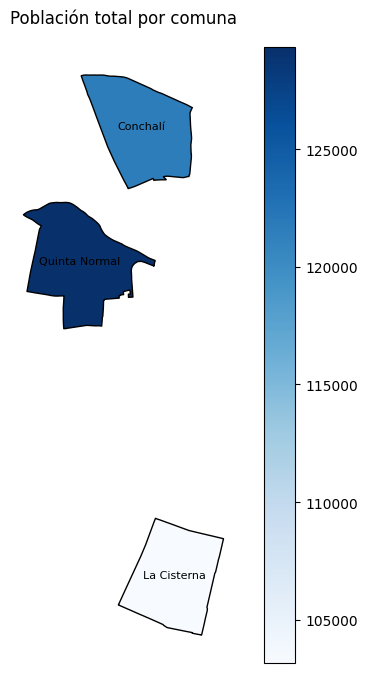

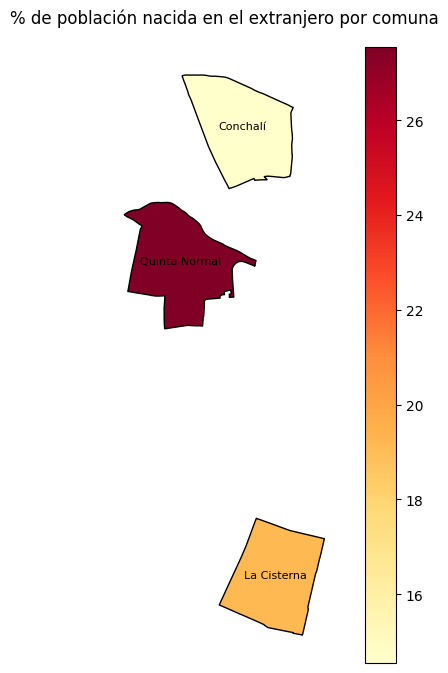

In [35]:
# PASO 3: Visualización espacial.

import os
import geopandas as gpd
import matplotlib.pyplot as plt

# Mapeo de nombres de comunas
comuna_names = {
    13104: "Conchalí",
    13109: "La Cisterna",
    13126: "Quinta Normal"
}

# Tus comunas
MY_COMUNAS = [13104, 13109, 13126]

# Ruta del shapefile
# Ajusta esta ruta si tu shapefile está en otra carpeta
SHP_PATH = "/content/drive/MyDrive/Tarea1_Censo/viv_hog_per_censo2024/comunas.shp"

# Cargar shapefile
comunas_gdf = gpd.read_file(SHP_PATH)

print("Columnas shapefile:")
print(comunas_gdf.columns)

# Ajustar nombre de columna de código de comuna
# En tu shapefile real viene como 'cod_comuna'
comunas_gdf = comunas_gdf.rename(columns={"cod_comuna": "codigo_comuna"})

# Asegurar tipo numérico
comunas_gdf["codigo_comuna"] = comunas_gdf["codigo_comuna"].astype(int)

# Filtrar solo a tus 3 comunas
comunas_gdf = comunas_gdf[comunas_gdf["codigo_comuna"].isin(MY_COMUNAS)].copy()

# Agregar nombre legible
comunas_gdf["comuna_label"] = comunas_gdf["codigo_comuna"].map(comuna_names)

# Construir tabla agregada desde df
agg = (
    df.groupby("codigo_comuna")
      .agg(
          pop_total=("id_persona", "count"),
          pop_foreign=("p25_lug_nacimiento_rec", lambda x: (x == 2).sum())
      )
      .reset_index()
)

agg["pct_foreign"] = agg["pop_foreign"] / agg["pop_total"] * 100
agg["comuna_label"] = agg["codigo_comuna"].map(comuna_names)

print("Tabla agregada:")
display(agg)

# Merge con shapefile
map_df = comunas_gdf.merge(agg, on=["codigo_comuna", "comuna_label"], how="left")

print("Resultado merge:")
display(map_df[["codigo_comuna", "comuna_label", "pop_total", "pct_foreign"]])


# 3.1 Mapa población total
fig, ax = plt.subplots(figsize=(8, 8))

map_df.plot(
    column="pop_total",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Población total por comuna")
ax.axis("off")

for _, row in map_df.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["comuna_label"], fontsize=8, ha="center")

plt.show()

# 3.2 Mapa % extranjeros

fig, ax = plt.subplots(figsize=(8, 8))

map_df.plot(
    column="pct_foreign",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("% de población nacida en el extranjero por comuna")
ax.axis("off")

for _, row in map_df.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["comuna_label"], fontsize=8, ha="center")

plt.show()

Comentario:

Los mapas muestran diferencias entre las comunas tanto en tamaño poblacional como en proporción de población extranjera.

Se observa que la distribución de población extranjera no es homogénea, lo que sugiere que ciertos territorios concentran una mayor proporción de migrantes, posiblemente debido a factores como redes sociales, oportunidades laborales o disponibilidad de vivienda.

Dado que se analizan solo tres comunas, las diferencias son más fáciles de visualizar y comparar directamente.

Parte 4: Tabla resumen

In [36]:

# PASO 4: TABLA RESUMEN COMUNAL

import os
import numpy as np
import pandas as pd

# Códigos base
COD_CHILEAN_BORN = 1
COD_FOREIGN_BORN = 2
COD_EMPLOYED = 1

# Nombres de comunas
comuna_names = {
    13104: "Conchalí",
    13109: "La Cisterna",
    13126: "Quinta Normal"
}

def build_summary(group):
    valid_age = group["edad"].notna()
    valid_school = group["escolaridad"].notna()
    valid_emp = group["sit_fuerza_trabajo"].notna()

    ch = group["p25_lug_nacimiento_rec"] == COD_CHILEAN_BORN
    fg = group["p25_lug_nacimiento_rec"] == COD_FOREIGN_BORN

    pop_total = len(group)
    pop_chilean = ch.sum()
    pop_foreign = fg.sum()
    pct_foreign = (pop_foreign / pop_total * 100) if pop_total > 0 else np.nan

    median_age_chilean = group.loc[ch & valid_age, "edad"].median()
    median_age_foreign = group.loc[fg & valid_age, "edad"].median()

    mean_schooling_chilean = group.loc[
        ch & valid_age & valid_school & (group["edad"] >= 25),
        "escolaridad"
    ].mean()

    mean_schooling_foreign = group.loc[
        fg & valid_age & valid_school & (group["edad"] >= 25),
        "escolaridad"
    ].mean()

    emp_ch = group.loc[
        ch & valid_age & valid_emp & group["edad"].between(15, 64),
        "sit_fuerza_trabajo"
    ]

    emp_fg = group.loc[
        fg & valid_age & valid_emp & group["edad"].between(15, 64),
        "sit_fuerza_trabajo"
    ]

    emp_rate_chilean = (emp_ch == COD_EMPLOYED).mean() if len(emp_ch) > 0 else np.nan
    emp_rate_foreign = (emp_fg == COD_EMPLOYED).mean() if len(emp_fg) > 0 else np.nan

    young = ((group["edad"] >= 0) & (group["edad"] <= 14)).sum()
    old = (group["edad"] >= 65).sum()
    working = ((group["edad"] >= 15) & (group["edad"] <= 64)).sum()
    dependency_ratio = ((young + old) / working) if working > 0 else np.nan

    codigo = group["codigo_comuna"].iloc[0]

    return pd.Series({
        "codigo_comuna": codigo,
        "nombre_comuna": comuna_names.get(codigo, str(codigo)),
        "pop_total": pop_total,
        "pop_chilean": pop_chilean,
        "pop_foreign": pop_foreign,
        "pct_foreign": pct_foreign,
        "median_age_chilean": median_age_chilean,
        "median_age_foreign": median_age_foreign,
        "mean_schooling_chilean": mean_schooling_chilean,
        "mean_schooling_foreign": mean_schooling_foreign,
        "emp_rate_chilean": emp_rate_chilean,
        "emp_rate_foreign": emp_rate_foreign,
        "dependency_ratio": dependency_ratio
    })

summary = (
    df.groupby("codigo_comuna", group_keys=False)
      .apply(build_summary)
      .reset_index(drop=True)
      .sort_values("codigo_comuna")
)

print("Tabla resumen final:")
display(summary)

# Guardar CSV
OUTPUT_PATH = "/content/drive/MyDrive/Tarea1_Censo/output"
os.makedirs(OUTPUT_PATH, exist_ok=True)

summary_path = os.path.join(OUTPUT_PATH, "tarea1_comuna_summary.csv")
summary.to_csv(summary_path, index=False)

print("Archivo guardado en:", summary_path)

Tabla resumen final:


/tmp/ipykernel_186/894958048.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(build_summary)


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13104,Conchalí,121587,103271,17686,14.545963,39.0,34.0,11.325066,11.983653,0.610039,0.751039,0.478603
1,13109,La Cisterna,103157,82209,19762,19.157207,37.0,32.0,12.724804,13.401107,0.674023,0.787796,0.447939
2,13126,Quinta Normal,129351,92347,35630,27.545206,38.0,32.0,11.942872,12.615201,0.655335,0.781131,0.434953


Archivo guardado en: /content/drive/MyDrive/Tarea1_Censo/output/tarea1_comuna_summary.csv


Comentario:

La tabla resumen permite comparar de manera directa los principales indicadores entre las tres comunas.

Se observa que la población extranjera representa una fracción relevante del total y tiende a ser más joven y con mayor participación en el mercado laboral.

Por otro lado, la población chilena presenta mayores niveles de escolaridad promedio. La razón de dependencia es relativamente baja en todas las comunas, lo que confirma una estructura demográfica dominada por población en edad de trabajar.

Conclusion:

En conjunto, los resultados muestran que las comunas de Conchalí, La Cisterna y Quinta Normal presentan una estructura demográfica caracterizada por una alta proporción de población en edad laboral y una presencia significativa de población migrante.

La migración se concentra en individuos en edad activa, con altas tasas de empleo y llegada reciente, lo que sugiere que juega un rol importante en la dinámica económica local.

Al mismo tiempo, existen diferencias en escolaridad y distribución territorial que reflejan distintos patrones de integración.

Estos resultados evidencian la importancia de considerar la dimensión migratoria en el análisis demográfico y en el diseño de políticas públicas a nivel comunal.